## CRCA for loading $v(s_j,t_i)^+$ into a quantum circuit

In [3]:
%load_ext autoreload
%autoreload 2

from quantum_cva.multi_asset.classical.probability_and_underlying.multi_asset_dynamics_utils import (
    simulate_multi_asset_gbm,
)

from quantum_cva.multi_asset.classical.probability_and_underlying.multi_asset_discrete_probability_utils import (
    grid_and_prob_tensor_multiasset,
)

from quantum_cva.multi_asset.quantum.training.utilities.cross_validation_utils import SPSAHyperparamCV
from quantum_cva.multi_asset.quantum.training.utilities.circuit_training_tools import (
    plot_training_diagnostics,
    minimize_with_cost_history,
)
from quantum_cva.multi_asset.quantum.training.functional_encoding_crca.crca_circuit import CrcaCircuit

import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from qiskit_algorithms.optimizers import SPSA

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


(Positive) Exposure calculation. 

(This will be done in CVA_MC_benchmark.ipynb and we will download the output exposure from that notebook)

In [4]:
# =============================
# Simulation parameters
# =============================
S0 = 5.0
K = 5.5
sigma = 0.25
mu = 0.02
r = mu # approx flat curve equal to drift

n_sigma = 3.0
n_paths = 10**5

# n=2 -> N=4, m=2 -> M=4
n, m = 2, 2
N, M = 2**n, 2**m

T = 184/360

In [5]:
t_coarse = np.linspace(0.0, T, M + 1)[1:]  # M exposure dates (t=0 excluded)

rho_1d = np.array([[1.0]], dtype=float)
Z_coarse = np.random.standard_normal(size=(n_paths, M, 1))  # shape (N_paths, M, d=1)
S_raw = simulate_multi_asset_gbm(
    S0=[S0], mu=[r], sigma=[sigma],
    rho=rho_1d,
    t=t_coarse,
    Z=Z_coarse,
    antithetic=False,
    pathwise=True,
)
S_by_time_coarse = [S_raw[:, i, :] for i in range(S_raw.shape[1])]

grid, _ = grid_and_prob_tensor_multiasset(S_by_time_coarse, n_bits=[n], n_sigma=n_sigma)
edges = grid.edges_list[0]
s_mid = grid.rep_list[0]
#! left repr to obtain more similar graphics 
s_rep = edges[:-1]     #left
#s_rep = edges[1:] #right
#s_rep = s_mid   # mid

v_pos = np.empty((M, N), dtype=float)

for i in range(M):
    ti = float(t_coarse[i])
    fwd_strike_i = K * np.exp(-r * (T - ti))   # K*exp(-r*(T-ti))
    v_pos[i, :] = np.maximum(s_rep - fwd_strike_i, 0.0)

print("v_pos shape:", v_pos.shape)  # (4,4)

v_pos shape: (4, 4)


In [6]:
# We reescale it
v_vec = np.asarray(v_pos, dtype=float).reshape(M * N)  # i*N + j


C = float(np.max(v_vec))
if C <= 0.0:
    positive_exposure_target = np.zeros_like(v_vec)
else:
    positive_exposure_target = v_vec / C

print("Scaling constant = ", C)
print("len(positive_exposure_target) =", positive_exposure_target.size, "(expected", M*N, ")")
print("max(positive_exposure_target) =", positive_exposure_target.max(), "  (C =", C, ")")

print(positive_exposure_target)

Scaling constant =  0.9669755374360944
len(positive_exposure_target) = 16 (expected 16 )
max(positive_exposure_target) = 1.0   (C = 0.9669755374360944 )
[0.         0.         0.         1.         0.         0.
 0.         0.98555698 0.         0.         0.         0.971077
 0.         0.         0.         0.95655998]


CRCA circuit building

In [7]:
m_time = 2
n_price = 2

In [8]:
crca = CrcaCircuit(
    m_time=m_time,
    n_price=n_price,
    n_layers=2,      
    name="CRCA_df",
)

qc = crca.qc

print(qc.draw(output="text", fold=120))

                                                                                                                     »
t_0: ───────────────────────────────────────────────────────■───────────────■───────────────■────────────────────────»
                                                            │               │               │                        »
t_1: ───────────────────────────────────────────────────────┼───────────────┼───────────────┼───────────────■────────»
                                                            │               │               │               │        »
s_0: ───────────────────────────────────────────────────────┼───────────────┼───────────────┼───────────────┼────────»
                                                            │               │               │               │        »
s_1: ───────────────────────────────────────────────────────┼───────────────┼───────────────┼───────────────┼────────»
     ┌──────────────┐┌──────────────┐┌──────────

CRCA circuit training

In [24]:
# -------------------------
# Fixed hyperparameters
# -------------------------
SEED = 100
N_ITERS = 1000
METHOD = "COBYLA"

1. Ideal (statevector) setting

In [31]:
RHOBEG = 0.1
rng = np.random.default_rng(SEED)

# -------------------------
# Initial parameters
# -------------------------
x0 = rng.standard_normal(crca.n_params).astype(float)

# -------------------------
# Define L2 cost (ideal, statevector)
# -------------------------
cost = crca.cost_fn(positive_exposure_target, shots=None)

# -------------------------
# Run optimization
# -------------------------
res, cost_history = minimize_with_cost_history(
    cost,
    x0=x0,
    minimize_fn=minimize,
    method=METHOD,
    options={
        "maxiter": int(N_ITERS),
        "rhobeg": RHOBEG,
        "disp": True,
    },
)

theta_star = np.asarray(res.x, dtype=float)

# -------------------------
# Diagnostics
# -------------------------
f0 = 0.1 * crca.function_values(x0, shots=None)
f_star_statevector = crca.function_values(theta_star, shots=None)

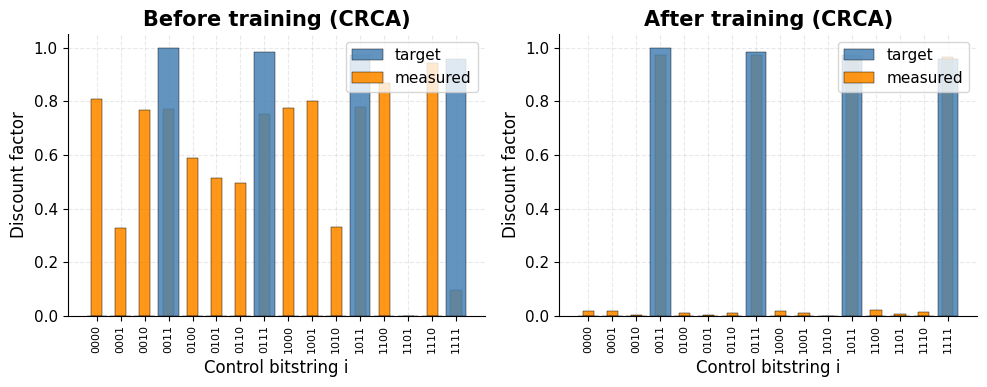

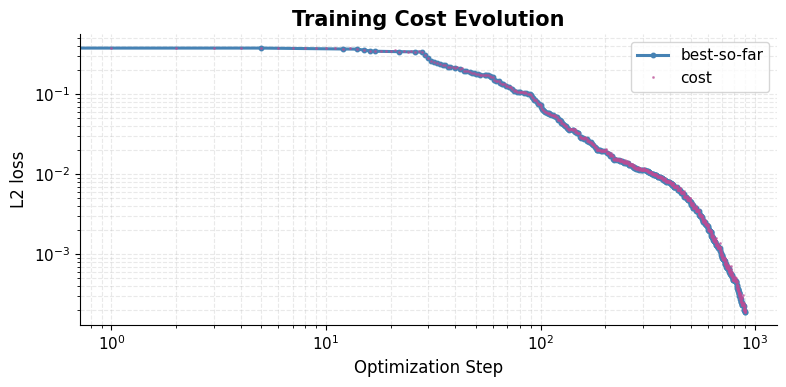

In [32]:
theta_star = np.asarray(res.x, dtype=float)

# 2) Recompute before/after function values
f0 = crca.function_values(x0, shots=None)
f_star = crca.function_values(theta_star, shots=None)

# 3) best-so-far curve and indices
best_so_far = np.minimum.accumulate(cost_history)
tol = 1e-15
best_idx = np.flatnonzero(np.r_[True, best_so_far[1:] < best_so_far[:-1] - tol])

# 4) Labels (bitstrings of length n_controls)
labels = [format(i, f"0{crca.n_controls}b") for i in range(crca.dim_controls)]

plot_training_diagnostics(
    target=positive_exposure_target,
    before=f0,
    after=f_star,
    cost_history=cost_history,
    best_so_far=best_so_far,
    best_idx=best_idx,
    labels=labels,
    xlabel="Control bitstring i",
    ylabel="Discount factor",
    cost_ylabel="L2 loss",
    title_before="Before training (CRCA)",
    title_after="After training (CRCA)",
    cost_log_x=True,
    cost_log_y=True
)
plt.show()

2. Shots-based setting

In [33]:
# =========================
# Shot-based training for CRCA with SPSA 
# =========================
N_ITERS = 900
SHOTS = 5000

# fixed-shot objective
cost_shots = crca.cost_fn(positive_exposure_target, shots=SHOTS, seed=None)

cost_history: list[float] = []

# guardar mejor
best = {
    "fx": float("inf"),
    "x": np.asarray(x0, dtype=float).copy(),
}

def spsa_cb(nfev, x, fx, stepsize, accepted):
    fx = float(fx)
    cost_history.append(fx)
    if fx < best["fx"]:
        best["fx"] = fx
        best["x"] = np.asarray(x, dtype=float).copy()

# -------------------------
# SPSA setup
# -------------------------
opt = SPSA(
    maxiter=int(N_ITERS),
    learning_rate=0.45,
    perturbation=0.09,
    blocking=False,
    trust_region=True,
    callback=spsa_cb,
)

# -------------------------
# Run optimization
# -------------------------
res = opt.minimize(fun=cost_shots, x0=x0)

theta_last = np.asarray(res.x, dtype=float)
theta_best = best["x"].copy()

# -------------------------
# Diagnostics (BEST iteration)
# -------------------------
f_star_best = crca.function_values(theta_best, shots=SHOTS, seed=None)

# -------------------------
# Cost history + best-so-far
# -------------------------
cost_history = np.asarray(cost_history, dtype=float)
best_so_far = np.minimum.accumulate(cost_history)
tol = 1e-15
best_idx = np.flatnonzero(np.r_[True, best_so_far[1:] < best_so_far[:-1] - tol])

labels = [format(i, f"0{crca.n_controls}b") for i in range(crca.dim_controls)]

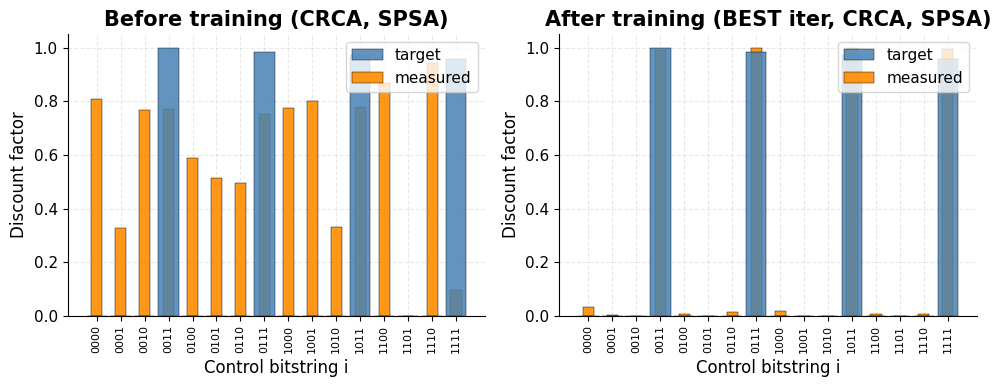

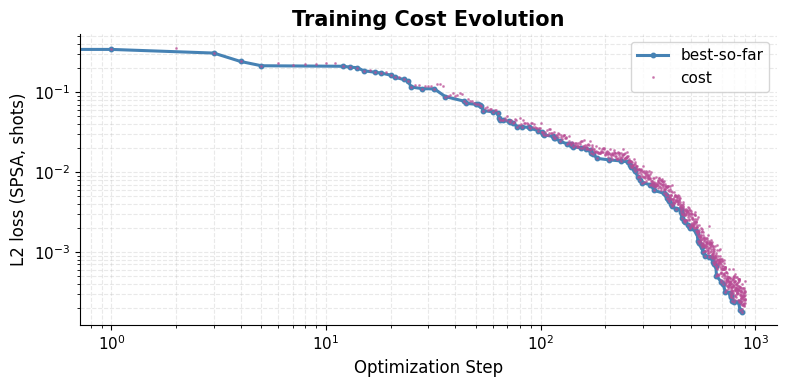

In [34]:
plot_training_diagnostics(
    target=positive_exposure_target,
    before=f0,
    after=f_star_best,   
    cost_history=cost_history,
    best_so_far=best_so_far,
    best_idx=best_idx,
    labels=labels,
    xlabel="Control bitstring i",
    ylabel="Discount factor",
    cost_ylabel="L2 loss (SPSA, shots)",
    title_before="Before training (CRCA, SPSA)",
    title_after="After training (BEST iter, CRCA, SPSA)",
    cost_log_x=True,
    cost_log_y=True,
)
plt.show()